<a href="https://colab.research.google.com/github/Aziz4785/ML/blob/master/GLOW_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import kagglehub
from PIL import Image
import numpy as np
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import math
import torch.nn.functional as F

class Config:
    DATASET = "celebahq64"
    BATCH_SIZE = 64 #use 64 or 32

config = Config()


In [2]:
if config.DATASET == "faces_64x64":
  path = kagglehub.dataset_download(
      "ashwingupta3012/human-faces",
      force_download=True
  )
elif config.DATASET == "celebahq64":
  path = kagglehub.dataset_download("badasstechie/celebahq-resized-256x256")

print("Dataset downloaded to:", path)


def center_crop_to_square(img: Image.Image) -> Image.Image:
    w, h = img.size
    if w == h:
        return img
    if w > h:
        left = (w - h) // 2
        right = left + h
        top = 0
        bottom = h
    else:
        top = (h - w) // 2
        bottom = top + w
        left = 0
        right = w
    return img.crop((left, top, right, bottom))

100%|██████████| 283M/283M [00:01<00:00, 170MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/badasstechie/celebahq-resized-256x256/versions/1


In [3]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def generate_and_show_images(model, epoch, num_images=16, temperature=0.7, device='cuda'):
    model.eval()

    with torch.no_grad():
        # image_size should match config.DATASET processing (3 channels, 64x64)
        generated_images = model.sample(
            num_samples=num_images,
            image_size=(3, 64, 64),
            temperature=temperature,
            device=device
        )

    generated_images = generated_images.cpu()

    grid = make_grid(generated_images, nrow=int(num_images**0.5), padding=2, normalize=False)

    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title(f"Generated Images at Epoch {epoch} (Temp: {temperature})")
    plt.show()
    model.train()

make the dataset 64*64 :

In [4]:
input_dir = path
output_dir = "/content/faces_64x64/faces"

os.makedirs(output_dir, exist_ok=True)

count = 0

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(root, file)
            try:
                img = Image.open(img_path).convert("RGB")
                img = center_crop_to_square(img)
                img = img.resize((64, 64), Image.BICUBIC)

                save_path = os.path.join(output_dir, file)
                img.save(save_path)

                count += 1
            except:
                print("Error loading:", img_path)

print(f"Done! Processed {count} images into {output_dir}")

Done! Processed 30000 images into /content/faces_64x64/faces


In [5]:


transform = transforms.Compose([
    transforms.ToTensor(),   # gives [0,1]
])

dataset = datasets.ImageFolder(
    root="/content/faces_64x64",
    transform=transform
)

train_loader = DataLoader(
    dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

In [6]:
import torch
import torch.nn as nn

class GenerateParameters(nn.Module):
    # warning : the number of channels changes at each level after a split()
    def __init__(self, in_channels):
        super().__init__()
        # In Glow, we output exactly double the channels of the input
        self.conv = nn.Conv2d(in_channels, in_channels * 2, kernel_size=3, padding=1)
        nn.init.zeros_(self.conv.weight)
        nn.init.zeros_(self.conv.bias)

    def forward(self, zkeep):
        # zkeep shape is (B,C,H,W)
        h = self.conv(zkeep)
        mu = h[:, 0::2, :, :]
        log_sigma = h[:, 1::2, :, :]

        return mu, log_sigma

In [7]:

class ActNorm(nn.Module):
    def __init__(self, num_channels, logscale_factor=3.):
        super().__init__()
        self.num_channels = num_channels
        self.logscale_factor = logscale_factor

        # In PyTorch, shape is (B, C, H, W).
        # We need parameters of shape (1, C, 1, 1) to broadcast correctly across batches and spatial dims.
        self.bias = nn.Parameter(torch.zeros(1, num_channels, 1, 1))
        self.logs = nn.Parameter(torch.zeros(1, num_channels, 1, 1))

        # Buffer to keep track of whether data-dependent initialization has occurred
        self.register_buffer('initialized', torch.tensor(0, dtype=torch.uint8))

    def initialize_parameters(self, x):
        """Data-dependent initialization using the first batch of data."""
        with torch.no_grad():
            # Calculate mean and variance over Batch, Height, and Width dimensions (dims 0, 2, 3)
            mean = x.mean(dim=(0, 2, 3), keepdim=True)
            var = x.var(dim=(0, 2, 3), keepdim=True)

            # actnorm_center: x + bias = 0  =>  bias = -mean
            self.bias.data.copy_(-mean)

            # actnorm_scale: (x + bias) * exp(logs * factor) has variance 1
            # var * exp(2 * logs * factor) = 1  =>  logs = -0.5 * log(var) / factor
            logs = -0.5 * torch.log(var + 1e-6) / self.logscale_factor
            self.logs.data.copy_(logs)

            self.initialized.fill_(1)

    def forward(self, x, logdet=None, reverse=False):
        # Perform data-dependent init on the first forward pass
        if self.initialized.item() == 0:
            self.initialize_parameters(x)

        # Glow scales the logs by a factor (usually 3.0) to keep gradients stable
        logs = self.logs * self.logscale_factor

        # Spatial dimensions H * W are needed for logdet
        B, C, H, W = x.shape

        if not reverse:
            x = x + self.bias
            x = x * torch.exp(logs)

            if logdet is not None:
                # log_det added per pixel. Total added is H * W * sum(logs)
                dlogdet = H * W * torch.sum(logs)
                logdet = logdet + dlogdet

        else:
            x = x * torch.exp(-logs)
            x = x - self.bias

            if logdet is not None:
                # Reverse subtracts the log determinant
                dlogdet = H * W * torch.sum(logs)
                logdet = logdet - dlogdet

        if logdet is not None:
            return x, logdet

        return x


class Invertible1x1Conv(nn.Module):
    """
    Invertible 1x1 convolution from Glow-style flows.

    Args:
        num_channels: number of input/output channels
        lu_decomposed: if True, use LU-parameterized version

    Forward:
        x, logdet = module(x, logdet=None, reverse=False)

    Shapes:
        x: [B, C, H, W]
        logdet: scalar tensor or [B] tensor or None
    """

    def __init__(self, num_channels: int, lu_decomposed: bool = False):
        super().__init__()
        self.num_channels = num_channels
        self.lu_decomposed = lu_decomposed

        # Random orthogonal initialization
        w_init = np.linalg.qr(np.random.randn(num_channels, num_channels))[0].astype(np.float32)
        w_init = torch.from_numpy(w_init)

        if not lu_decomposed:
            self.weight = nn.Parameter(w_init)
        else:
            # LU decomposition
            # torch.linalg.lu returns P, L, U such that P @ A = L @ U
            P, L, U = torch.linalg.lu(w_init)

            s = torch.diag(U)
            sign_s = torch.sign(s)
            log_s = torch.log(torch.abs(s))

            U = torch.triu(U, diagonal=1)
            L = torch.tril(L, diagonal=-1)

            self.register_buffer("P", P)
            self.register_buffer("sign_s", sign_s)
            self.L = nn.Parameter(L)
            self.log_s = nn.Parameter(log_s)
            self.U = nn.Parameter(U)

            self.register_buffer("l_mask", torch.tril(torch.ones(num_channels, num_channels), diagonal=-1))
            self.register_buffer("u_mask", torch.triu(torch.ones(num_channels, num_channels), diagonal=1))
            self.register_buffer("eye", torch.eye(num_channels))

    def _assemble_weight(self):
        if not self.lu_decomposed:
            return self.weight

        L = self.L * self.l_mask + self.eye
        U = self.U * self.u_mask + torch.diag(self.sign_s * torch.exp(self.log_s))
        W = self.P @ L @ U
        return W

    def _logdet(self, h: int, w: int):
        if not self.lu_decomposed:
            sign, logabsdet = torch.linalg.slogdet(self.weight.double())
            if sign == 0:
                raise RuntimeError("Weight matrix is singular.")
            return logabsdet.float() * (h * w)
        else:
            return torch.sum(self.log_s) * (h * w)

    def forward(self, x, logdet=None, reverse: bool = False):
        """
        Args:
            x: [B, C, H, W]
            logdet: None, scalar tensor, or [B] tensor
            reverse: whether to apply inverse transform

        Returns:
            z, logdet
        """
        B, C, H, W = x.shape
        if C != self.num_channels:
            raise ValueError(f"Expected {self.num_channels} channels, got {C}")

        weight = self._assemble_weight()
        dlogdet = self._logdet(H, W)

        if not reverse:
            weight_conv = weight.view(C, C, 1, 1)
            z = F.conv2d(x, weight_conv)
            if logdet is not None:
                logdet = logdet + dlogdet
            return z, logdet
        else:
            weight_inv = torch.inverse(weight.double()).float()
            weight_inv_conv = weight_inv.view(C, C, 1, 1)
            z = F.conv2d(x, weight_inv_conv)
            if logdet is not None:
                logdet = logdet - dlogdet
            return z, logdet



class ZeroConv2d(nn.Module):
    """
    this  predicts the shift and scale parameters
    It is A convolutional layer where weights and biases are initialized to zero.
    Used for the last layer of the coupling network.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        # Initialize weights and biases to exactly 0
        self.conv.weight.data.zero_()
        self.conv.bias.data.zero_()

    def forward(self, x):
        return self.conv(x)


class CouplingNetwork(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            ZeroConv2d(hidden_channels, out_channels)
        )

    def forward(self, x):
        return self.net(x)

class AffineCoupling(nn.Module):
  """
  The Affine Coupling mechanism from revnet2d_step.
  """
  def __init__(self, num_channels, hidden_channels):
      super().__init__()
      self.num_channels = num_channels

      # We split the input channels in half
      in_channels = num_channels // 2

      # The network needs to output both 'shift' and 'scale_params' for the other half.
      # So the output channels of the network equal the total number of channels.
      out_channels = num_channels

      self.f = CouplingNetwork(in_channels, hidden_channels, out_channels)

  def forward(self, x, logdet=None, reverse=False):
      # PyTorch format is (Batch, Channels, Height, Width)
      C = x.shape[1]
      C_half = C // 2

      # Split z into z1 and z2
      z1 = x[:, :C_half, :, :]
      z2 = x[:, C_half:, :, :]

      # Pass z1 through the neural network
      h = self.f(z1)

      # In TF: shift = h[:, :, :, 0::2], scale_params = h[:, :, :, 1::2]
      # In PyTorch, channel is dimension 1, so we slice dim 1
      shift = h[:, 0::2, :, :]
      scale_params = h[:, 1::2, :, :]

      # As per the specific TF code provided: tf.nn.sigmoid(h + 2.)
      scale = torch.sigmoid(scale_params + 2.0)

      if not reverse:
          z2 = z2 + shift
          z2 = z2 * scale

          if logdet is not None:
              # Sum the log of scale over C, H, W (dims 1, 2, 3)
              dlogdet = torch.sum(torch.log(scale), dim=(1, 2, 3))
              logdet = logdet + dlogdet

      else:
          z2 = z2 / scale
          z2 = z2 - shift

          if logdet is not None:
              dlogdet = torch.sum(torch.log(scale), dim=(1, 2, 3))
              logdet = logdet - dlogdet

      # Re-concatenate along the channel dimension
      z = torch.cat([z1, z2], dim=1)

      if logdet is not None:
          return z, logdet

      return z

In [8]:
class StepOfFlow(nn.Module): #it is called revnet2d_step in the original code
    """
    One full step of the flow: ActNorm -> 1x1Conv -> AffineCoupling
    Matches `revnet2d_step` in the TensorFlow code.
    """
    def __init__(self, num_channels, hidden_channels, lu_decomposed=False):
        super().__init__()

        self.actnorm = ActNorm(num_channels)

        self.invconv = Invertible1x1Conv(num_channels, lu_decomposed=lu_decomposed)

        self.coupling = AffineCoupling(num_channels, hidden_channels)

    def forward(self, x, logdet=None, reverse=False):
        if not reverse:
            x, logdet = self.actnorm(x, logdet, reverse=False)
            x, logdet = self.invconv(x, logdet, reverse=False)
            x, logdet = self.coupling(x, logdet, reverse=False)

        else:
            # Reversed order for reverse pass
            x, logdet = self.coupling(x, logdet, reverse=True)
            x, logdet = self.invconv(x, logdet, reverse=True)
            x, logdet = self.actnorm(x, logdet, reverse=True)

        if logdet is not None:
            return x, logdet

        return x


In [9]:



def preprocess(x, n_bits_x=8):
    #n_bits_x = 9 because use use image s that have pixels in range [0,255]
    x = x.float()
    if x.max() <= 1.0:
        x = x * 255.0

    if n_bits_x < 8:
        x = torch.floor(x / 2 ** (8 - n_bits_x))

    n_bins = 2 ** n_bits_x
    x = x / n_bins - 0.5
    return x, n_bins

def postprocess(x):
    x = x + 0.5
    x = torch.clamp(x, 0.0, 1.0)
    return x

def squeeze(x, factor=2):
    assert factor >= 1
    if factor == 1:
        return x

    B, C, H, W = x.shape
    assert H % factor == 0 and W % factor == 0

    x = x.view(B, C, H // factor, factor, W // factor, factor)
    x = x.permute(0, 1, 3, 5, 2, 4)
    x = x.reshape(B, C * factor * factor, H // factor, W // factor)

    return x

def unsqueeze(x):
    B, C, H, W = x.shape
    x = x.view(B, C // 4, 2, 2, H, W)
    x = x.permute(0, 1, 4, 2, 5, 3).contiguous()
    x = x.view(B, C // 4, H * 2, W * 2)
    return x

def split_forward(x, logdet, generate_parameters_module):
    # 1. Split x into two halves along the channel dimension (dim=1)
    zkeep, zi = torch.chunk(x, 2, dim=1)
    mu, log_sigma = generate_parameters_module(zkeep)
    #we suppose zi is from a N(mu,sigma) distribution

    eps = (zi - mu) * torch.exp(-log_sigma)
    #eps is the standardized version of zi: eps ~ N(0,1)

    # 4. Calculate log probability of zi (which is added to your objective/logdet)
    # log p(zi | zkeep) = -0.5 * (log(2*pi) + 2*log_sigma + eps**2)
    logp = -0.5 * (math.log(2 * math.pi) + 2 * log_sigma + eps ** 2)
    logp = torch.sum(logp, dim=[1, 2, 3]) # Sum over channels, height, width

    # Add log-probability to objective
    logdet = logdet + logp

    # Return zkeep to go to the next flow level, and save eps as the latent output
    return zkeep, logdet, eps

def split_reverse(zkeep, zi, generate_parameters_module):
    # 1. Predict parameters for zi conditioned on zkeep
    mu, log_sigma = generate_parameters_module(zkeep)

    # 2. Reverse the transformation to reconstruct zi from eps
    # zi = mu + eps * sigma
    zi = mu + zi * torch.exp(log_sigma)

    # 3. Concatenate them back together along the channel dimension
    x = torch.cat([zkeep, zi], dim=1)

    return x

def log_N(z, mean, std):
    # Calculate the element-wise log probability
    log_prob = -0.5 * math.log(2 * math.pi) - torch.log(std) - 0.5 * ((z - mean) / std) ** 2

    # Sum over all dimensions (and batch) to return a single scalar loss
    return torch.sum(log_prob)

def log_N_logstd(z, mean, log_std):
    # No torch.log() needed because the network already outputted log_std!
    # We use torch.exp(log_std) to get the variance safely.
    log_prob = -0.5 * math.log(2 * math.pi) - log_std - 0.5 * ((z - mean) ** 2 * torch.exp(-2 * log_std))

    return torch.sum(log_prob)

class GlowToy(nn.Module):
    def __init__(self, image_channels=3, L=3, K=2, hidden_channels=64):
        super().__init__()
        self.L = L
        self.K = K

        current_channels = image_channels
        self.flow_levels = nn.ModuleList()
        self.generate_parameters_modules = nn.ModuleList()
        print("current channels: ",current_channels)
        for level in range(L):
            print("for level L = ",level)
            current_channels *= 4  # after squeeze
            print(" current channels should be : ",current_channels)
            print(f" so we stack {K} instance of step_of_flow() ")
            level_flows = nn.ModuleList([
                StepOfFlow(current_channels, hidden_channels) for _ in range(K)
            ])
            self.flow_levels.append(level_flows)

            if level < L - 1:
                self.generate_parameters_modules.append(GenerateParameters(current_channels // 2))
                current_channels = current_channels // 2  # after split, keep half

        print("self.flow_levels is ")
        for level_idx, level_flows in enumerate(self.flow_levels):
            print(f"  Level {level_idx}: {len(level_flows)} StepOfFlow modules")
            for step_idx, step in enumerate(level_flows):
                print(f"    Step {step_idx}: {step.__class__.__name__}")

    def forward(self, x):
        B, C, H, W = x.shape
        num_pixels = C * H * W

        #x shape is [B, C, H, W])
        #x values is in [1,0]
        x, n_bins = preprocess(x)
        #x is in [-0.5, 0.5]
        x = x + torch.rand_like(x) / n_bins
        #x still in [-0.5, 0.5]
        #adding the random noise will make the images as if they are continious  :x_discrete ∈ {0,...,255} -> x_continuous = x / 256 + noise
        objective = torch.zeros(x.size(0), device=x.device)
        objective = objective - math.log(n_bins) * x[0].numel()
        split_level_idx = 0
        latents = []
        for level in range(self.L):
            x = squeeze(x)
            logdet = torch.zeros(x.size(0), device=x.device)

            for flow in self.flow_levels[level]:
                x, logdet = flow(x, logdet=logdet, reverse=False) #we pass logdet in the parameters, so it gets accumulated

            objective = objective + logdet

            if level < self.L - 1:
                zkeep, objective, zi_standardized = split_forward(
                    x,
                    objective,
                    self.generate_parameters_modules[split_level_idx]
                )
                latents.append(zi_standardized)
                split_level_idx += 1
                x = zkeep
            else:
                logp = -0.5 * (math.log(2 * math.pi) + x ** 2)
                logp = torch.sum(logp, dim=[1, 2, 3])
                objective = objective + logp
                latents.append(x)

        loss = -objective.mean()
        #if you think about it, we are trying to convert an image into a latent vector z. so we are finding the best way
        #to compress an image so that we keep the maximum of information.
        #THE LOSS depens on the number of pixel, so instead we calculate the Bits Per Dimension (BPD)
        bpd = loss / (math.log(2.0) * num_pixels)

        return bpd, latents
    @torch.no_grad()
    def sample(self, num_samples, image_size=(3, 64, 64), temperature=1.0, device=None):
        """
        Generates novel images by sampling from the prior and reversing the flow.
        """
        self.eval()
        if device is None:
            device = next(self.parameters()).device

        C, H, W = image_size

        # 1. Calculate the spatial and channel dimensions for each level of the flow
        shapes =[]
        current_channels = C
        current_H, current_W = H, W

        for level in range(self.L):
            current_channels *= 4
            current_H //= 2
            current_W //= 2

            if level < self.L - 1:
                # After split, we keep half the channels
                shapes.append((current_channels // 2, current_H, current_W))
                current_channels = current_channels // 2
            else:
                # At the top level, we keep all remaining channels
                shapes.append((current_channels, current_H, current_W))

        # 2. Sample from the Gaussian Prior for the top-most latent space
        z = torch.randn(num_samples, *shapes[-1], device=device) * temperature

        # 3. Reverse the flow at the top level
        for flow in reversed(self.flow_levels[-1]):
            z, _ = flow(z, logdet=torch.zeros(num_samples, device=device), reverse=True)

        # VERY IMPORTANT: Reverse the spatial squeeze for the top level
        z = unsqueeze(z)

        # 4. Traverse backwards through the remaining multiscale levels
        for level in reversed(range(self.L - 1)):
            # Sample the latent 'eps' that was split off at this level
            eps = torch.randn(num_samples, *shapes[level], device=device) * temperature

            # Combine the current stream (zkeep) with the newly sampled latent (eps)
            z = split_reverse(
                zkeep=z,
                zi=eps,
                generate_parameters_module=self.generate_parameters_modules[level]
            )

            # Reverse the flow blocks for this level
            for flow in reversed(self.flow_levels[level]):
                z, _ = flow(z, logdet=torch.zeros(num_samples, device=device), reverse=True)

            # Reverse the spatial squeeze for this level
            z = unsqueeze(z)

        # 5. Transform back from continuous[-0.5, 0.5] to discrete pixels [0, 1]
        x = postprocess(z)
        return x


In [10]:
def get_lr(step, warmup_steps, base_lr):
    return base_lr * min(1., step / warmup_steps)

current channels:  3
for level L =  0
 current channels should be :  12
 so we stack 22 instance of step_of_flow() 
for level L =  1
 current channels should be :  24
 so we stack 22 instance of step_of_flow() 
for level L =  2
 current channels should be :  48
 so we stack 22 instance of step_of_flow() 
for level L =  3
 current channels should be :  96
 so we stack 22 instance of step_of_flow() 
self.flow_levels is 
  Level 0: 22 StepOfFlow modules
    Step 0: StepOfFlow
    Step 1: StepOfFlow
    Step 2: StepOfFlow
    Step 3: StepOfFlow
    Step 4: StepOfFlow
    Step 5: StepOfFlow
    Step 6: StepOfFlow
    Step 7: StepOfFlow
    Step 8: StepOfFlow
    Step 9: StepOfFlow
    Step 10: StepOfFlow
    Step 11: StepOfFlow
    Step 12: StepOfFlow
    Step 13: StepOfFlow
    Step 14: StepOfFlow
    Step 15: StepOfFlow
    Step 16: StepOfFlow
    Step 17: StepOfFlow
    Step 18: StepOfFlow
    Step 19: StepOfFlow
    Step 20: StepOfFlow
    Step 21: StepOfFlow
  Level 1: 22 StepOfFlow mo

Epoch 1/1600: 100%|██████████| 468/468 [01:27<00:00,  5.32it/s, loss=3.86]


Epoch 1: total_loss = 2130.8770


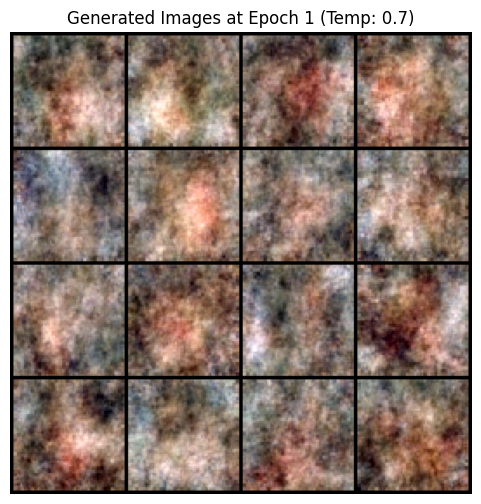

Epoch 2/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=3.45]


Epoch 2: total_loss = 1739.0402


Epoch 3/1600: 100%|██████████| 468/468 [01:25<00:00,  5.46it/s, loss=3.28]


Epoch 3: total_loss = 1605.4026


Epoch 4/1600: 100%|██████████| 468/468 [01:25<00:00,  5.46it/s, loss=3.14]


...

Epoch 13: total_loss = 1271.1536


Epoch 14/1600: 100%|██████████| 468/468 [01:24<00:00,  5.52it/s, loss=2.62]


Epoch 14: total_loss = 1257.9291


Epoch 15/1600: 100%|██████████| 468/468 [01:25<00:00,  5.50it/s, loss=2.66]


Epoch 15: total_loss = 1246.5634


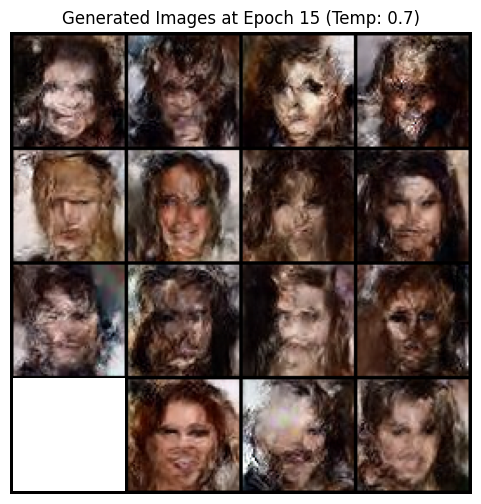

Epoch 16/1600: 100%|██████████| 468/468 [01:25<00:00,  5.45it/s, loss=2.63]


Epoch 16: total_loss = 1235.5328


Epoch 17/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.61]


Epoch 17: total_loss = 1226.3610


Epoch 18/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.58]


...

Epoch 28: total_loss = 1167.0717


Epoch 29/1600: 100%|██████████| 468/468 [01:24<00:00,  5.52it/s, loss=2.44]


Epoch 29: total_loss = 1164.1944


Epoch 30/1600: 100%|██████████| 468/468 [01:25<00:00,  5.50it/s, loss=2.50]

Epoch 30: total_loss = 1159.8824


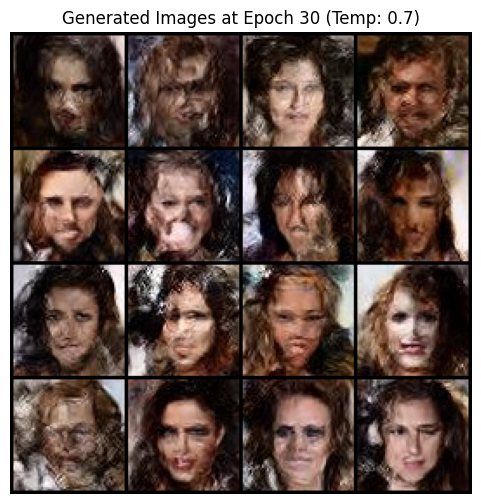

Epoch 31/1600: 100%|██████████| 468/468 [01:25<00:00,  5.49it/s, loss=2.46]


Epoch 31: total_loss = 1156.3935


Epoch 32/1600: 100%|██████████| 468/468 [01:25<00:00,  5.50it/s, loss=2.46]


Epoch 32: total_loss = 1153.2194


Epoch 33/1600: 100%|██████████| 468/468 [01:25<00:00,  5.49it/s, loss=2.45]


...

Epoch 43: total_loss = 1125.8141


Epoch 44/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.40]


Epoch 44: total_loss = 1122.6241


Epoch 45/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.43]


Epoch 45: total_loss = 1121.1656


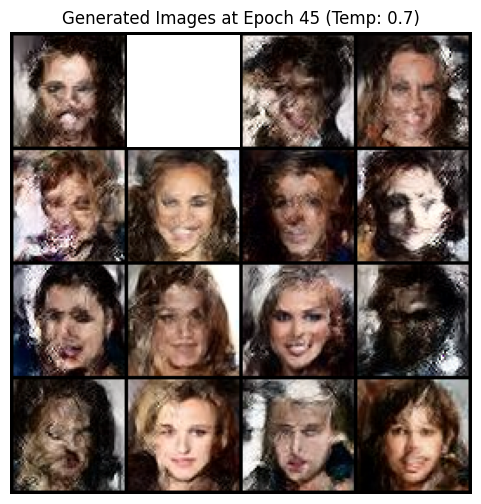

Epoch 46/1600: 100%|██████████| 468/468 [01:25<00:00,  5.50it/s, loss=2.38]


Epoch 46: total_loss = 1118.6015


Epoch 47/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.41]


Epoch 47: total_loss = 1115.8561


Epoch 48/1600: 100%|██████████| 468/468 [01:25<00:00,  5.49it/s, loss=2.39]


...

Epoch 58: total_loss = 1098.3303


Epoch 59/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.34]


Epoch 59: total_loss = 1096.5789


Epoch 60/1600: 100%|██████████| 468/468 [01:24<00:00,  5.51it/s, loss=2.35]


Epoch 60: total_loss = 1095.5885


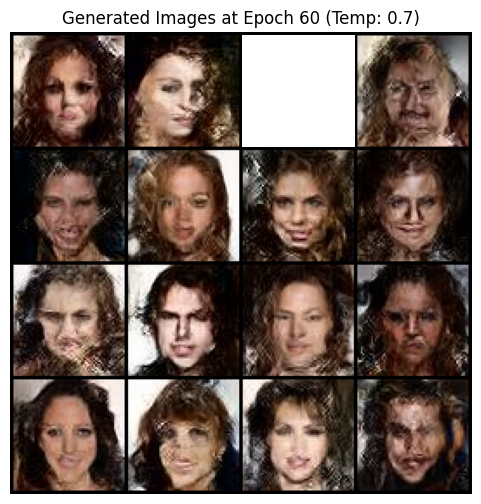

Epoch 61/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.36]


Epoch 61: total_loss = 1093.1225


Epoch 62/1600: 100%|██████████| 468/468 [01:25<00:00,  5.49it/s, loss=2.37]


Epoch 62: total_loss = 1091.3650


Epoch 63/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.32]


...

Epoch 73: total_loss = 1076.6930


Epoch 74/1600: 100%|██████████| 468/468 [01:25<00:00,  5.45it/s, loss=2.32]


Epoch 74: total_loss = 1075.6897


Epoch 75/1600: 100%|██████████| 468/468 [01:25<00:00,  5.49it/s, loss=2.30]

Epoch 75: total_loss = 1073.6339


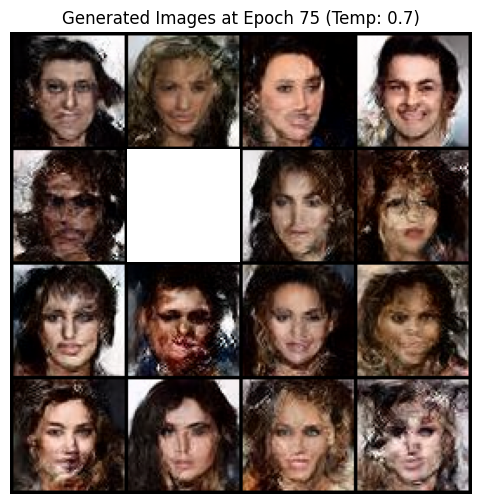

Epoch 76/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.29]


Epoch 76: total_loss = 1072.5174


Epoch 77/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.30]


Epoch 77: total_loss = 1071.7112


Epoch 78/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.30]


...

Epoch 88: total_loss = 1058.0770


Epoch 89/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.27]


Epoch 89: total_loss = 1057.5262


Epoch 90/1600: 100%|██████████| 468/468 [01:25<00:00,  5.46it/s, loss=2.26]


Epoch 90: total_loss = 1057.4339


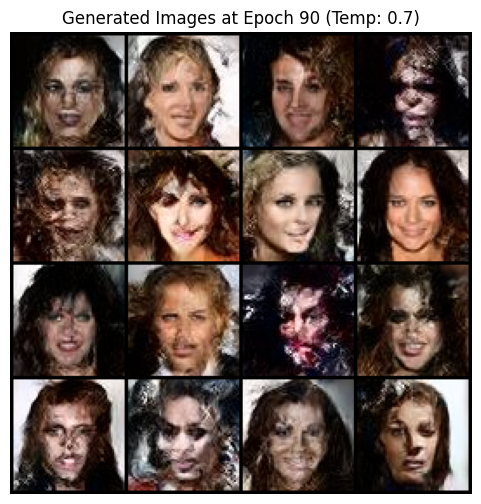

Epoch 91/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.24]


Epoch 91: total_loss = 1055.4609


Epoch 92/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.25]


Epoch 92: total_loss = 1055.2629


Epoch 93/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.22]


...

Epoch 103: total_loss = 1044.0748


Epoch 104/1600: 100%|██████████| 468/468 [01:25<00:00,  5.45it/s, loss=2.20]


Epoch 104: total_loss = 1043.7149


Epoch 105/1600: 100%|██████████| 468/468 [01:25<00:00,  5.45it/s, loss=2.23]


Epoch 105: total_loss = 1043.2753


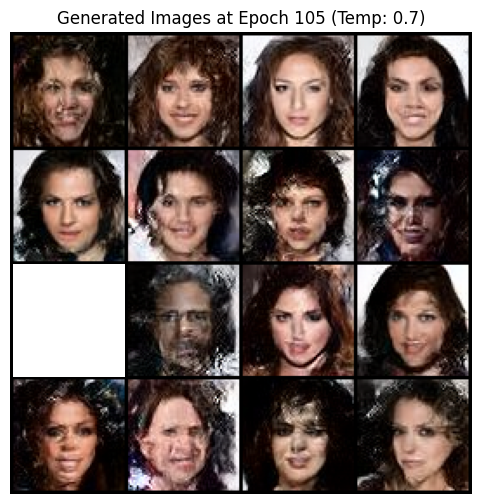

Epoch 106/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.18]


Epoch 106: total_loss = 1041.7161


Epoch 107/1600: 100%|██████████| 468/468 [01:25<00:00,  5.46it/s, loss=2.24]


Epoch 107: total_loss = 1040.4840


Epoch 108/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.28]


...

Epoch 118: total_loss = 1032.3110


Epoch 119/1600: 100%|██████████| 468/468 [01:25<00:00,  5.46it/s, loss=2.22]


Epoch 119: total_loss = 1030.9828


Epoch 120/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.14]


Epoch 120: total_loss = 1031.4116


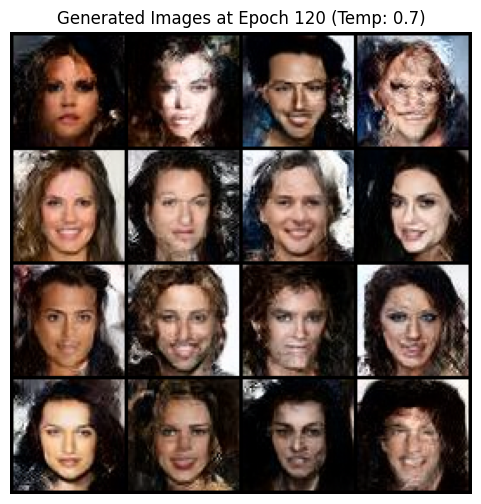

Epoch 121/1600: 100%|██████████| 468/468 [01:25<00:00,  5.45it/s, loss=2.19]


Epoch 121: total_loss = 1030.0674


Epoch 122/1600: 100%|██████████| 468/468 [01:25<00:00,  5.45it/s, loss=2.20]


Epoch 122: total_loss = 1029.7437


Epoch 123/1600: 100%|██████████| 468/468 [01:25<00:00,  5.46it/s, loss=2.23]


...

Epoch 133: total_loss = 1021.7898


Epoch 134/1600: 100%|██████████| 468/468 [01:25<00:00,  5.46it/s, loss=2.15]


Epoch 134: total_loss = 1020.9551


Epoch 135/1600: 100%|██████████| 468/468 [01:25<00:00,  5.45it/s, loss=2.20]

Epoch 135: total_loss = 1019.7073


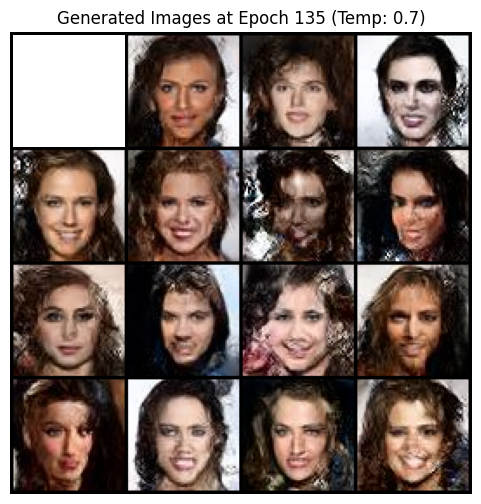

Epoch 136/1600: 100%|██████████| 468/468 [01:25<00:00,  5.48it/s, loss=2.20]


Epoch 136: total_loss = 1018.5839


Epoch 137/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.16]


Epoch 137: total_loss = 1018.9950


Epoch 138/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.19]


...

Epoch 148: total_loss = 1012.6321


Epoch 149/1600: 100%|██████████| 468/468 [01:25<00:00,  5.44it/s, loss=2.10]


Epoch 149: total_loss = 1011.4899


Epoch 150/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.17]


Epoch 150: total_loss = 1010.9684


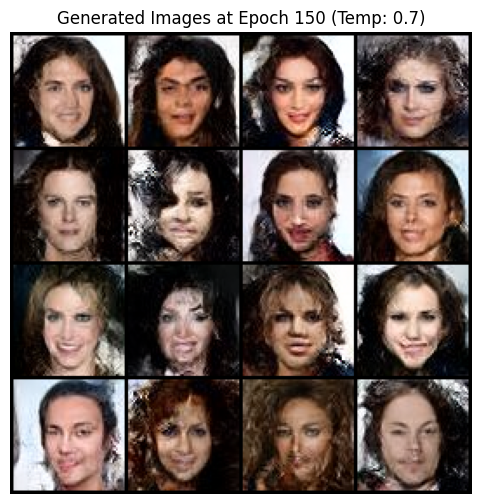

Epoch 151/1600: 100%|██████████| 468/468 [01:25<00:00,  5.47it/s, loss=2.13]


Epoch 151: total_loss = 1011.2444


Epoch 152/1600: 100%|██████████| 468/468 [01:25<00:00,  5.46it/s, loss=2.18]


Epoch 152: total_loss = 1009.2962


Epoch 153/1600:  24%|██▍       | 114/468 [00:20<01:04,  5.47it/s, loss=2.12]

In [ ]:


L = 4 #--n_levels in the official code (they used L between 3 and 6 included) (file : train.py)
K = 22 #--depth in the official code (they used 32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_lr = 1e-3
warmup_epochs = 10
hidden_channel = 512 #in the offical code they use 512
total_steps_warmup = warmup_epochs * len(train_loader) # Total batches in warmup


model = GlowToy(image_channels=3, L=L, K=K, hidden_channels=hidden_channel).to(device)

optimizer = torch.optim.Adamax(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999)
)

epochs = 1600 # in the offical code they trained for 1000000 epochs

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for step_in_epoch, (x, _) in enumerate(progress_bar):
        x = x.to(device)
        global_step = epoch * len(train_loader) + step_in_epoch
        lr_scale = min(1.0, float(global_step + 1) / total_steps_warmup)
        current_lr = base_lr * lr_scale
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr

        optimizer.zero_grad()
        loss,z = model(x)
        loss.backward()

        # Gradient clipping is highly recommended for GLOW to prevent NaNs #SEE IF IT IMPLEMENTED IN THE ORIGINAL VERSION
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.2f}")

    print(f"Epoch {epoch+1}: total_loss = {total_loss:.4f}")
    if (epoch + 1) % 15 == 0 or epoch == 0:
        generate_and_show_images(model, epoch=epoch+1, num_images=16, temperature=0.7, device=device)
